##### __!!!Antes de rodar esse notebook rode o primeiro, ele acessa a instância do grafo criada no outro!!!__

# __Métricas__

## __Introdução__
Para produzirmos nossa análise, exploramos algumas métricas relevantes, incluíndo aquelas associadas ao próprio grafo e suas entidades

Neste notebook vamos calcular e explorar alguns dos dados e de suas implicações.

## __Sobre o Grafo__

Como já exploramos anteriormente (no primeiro notebook), nosso grafo é constituído de 313 vértices - 312 times mais um vértice especial - e 508 arestas -sentidos das transferências -.

Visualizando sua plotagem, podemos observar algumas caractéristicas interessantes, a mais marcante delas, é a subdivisão da população em duas "macro comunidades", uma central e mais conectada entre si e uma segunda periférica que orbita a central, menos inteconectada entre si.

In [61]:
from matplotlib import pyplot

%store -r graph
%store -r layout

### __Métricas do Grafo__

#### __Densidade__

A densidade do nosso grafo é relativamente baixa (aproximadamente $ 0.00520 $), o que indica que para o período e para a quantidade dos times avaliados os times não desenvolvem muitas relações entre si.

Esse comportamento era esperado e reforça que em especial para times de ligas mais competitivas, a negociação de atletas é uma movimentação que ocorre mediante planejamento. O contexto em que o time está inserido costuma influênciar muito. 

#### __Clustering__

O custering médio do nosso grafo também é relativamente baixo, mas muito maior que a densidade (aproximadamente $ 0.0103 $ praticamente o dobro da densidade) o que pode indicar a existência de algumas comunidades bem definidas com fluxos mais intensos de atletas. 

#### __Diametro__

Nosso grafo possuí um diâmetro infinito, isso é uma caracteristica associada a interconectivdade dos seus vértices, para nosso caso, o grafo não é fortmente conectado, isso é um índicio de que podem existir subcomunidades desconexas dos principais fluxos de atletas. Um fato que pode ser atestado pelo prório plot do grafo (observe com atenção a região sudoeste, é possível ver um par de vértices desconexos do bloco principal). 

__Nota:__ Recortando essas comunidades desconexas, é possível encontrar o diâmetro da maior comunidade, que no caso seria igual a $ 15 $

In [62]:
from src.metrics import get_graph_metrics

graph_metrics = get_graph_metrics(graph)

for metric, value in graph_metrics.items():
    print(f"{metric} : {value}")

size : 508
order : 313
density : 0.005201933316949291
clustering : 0.010317527390189088
diameter : O grafo possuí diametro infinito (possivelmente é fracamente conectado)


### __Sobre multiplas transferências__

No primeiro notebook, dissertamos sobre a escolha de usar as arestas para representar os sentidos das transferências e não as trasnferências em si. Teoricamente isso é imporvavel, tendo em vista que as negociações acontecem em janelas de tempo muito bem defindas para cada uma das ligas.

A maior parte dos casos em que isso ocorre, estamos falando de atletas que são emprestados para um time, e logo em seguida são contratados numa especie de "test-drive" dos jogadores, em outros ainda mais raros, jogadores contratados como reserva são emprestados a outros times. Apesar de raros esses casos existem, e julgamos relevante representa-los

O histograma abaixo representa a distribuição da quantidade de transferências por aresta, note que só existem duas exceções para a regra proposta anteriormente (sendo uma delas o vértice especial)  em $ +500 $ registros, uma parcela muito baixa, que torna o erro praticamente irrelevante.

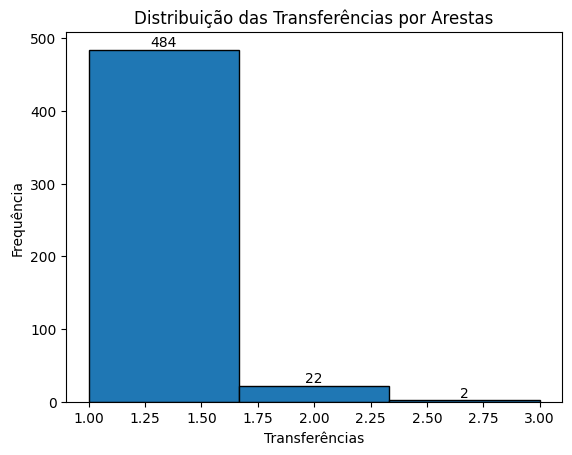

In [63]:
from src.metrics import get_transfers_quantities
from src.visualization import list_to_histogram

transfers_quantities = get_transfers_quantities(graph)

list_to_histogram(
    pyplot,
    transfers_quantities,
    3,
    "Distribuição das Transferências por Arestas",
    "Transferências",
    "Frequência"
)

## __Distribuição das Centralidades (Vértices)__

_Nas células abaixo vamos destrinchar em profundidade como se dão as distribuições das centralidades de nosso grafo uma por uma._

In [64]:
from src.metrics import get_sorted_centralities
from src.visualization import dict_to_histogram
from src.visualization import draw_styled_table

### __Centralidades de Grau__

As __centralidades de grau__ são calculadas a partir do grau de cada vértice do grafo. Para nossa modelagem essas essas centralidades seguem distribuições muito parecidas (a maior parte está incluída em casos de leis de potência), ou seja nosso grafo tem poucos hubs, mas que são característcos.

_Abaixo seguem as seções com as distribuições de centralidades de grau em tabelas e histogramas_

#### __Absoluto__

A __centralidade de grau absoluto__ nos ajuda a entender o volume total de transferências realizadas por cada clube.

In [65]:
from networkx import degree_centrality

absolute_degree_centralities = get_sorted_centralities(graph, degree_centrality)

In [66]:
# Geração da tabela com centralidades: Grau (Absoluto) 
draw_styled_table(
    absolute_degree_centralities,
    "Grau (Absoluto)",
    "Clubes"
)

,Clubes,Grau (Absoluto)
0,Chelsea,0.067308
1,Aston Villa,0.064103
2,Manchester City,0.054487
3,Brighton & Hove Albion,0.054487
4,Sem time,0.054487
5,AC Milan,0.051282
6,CF Montréal,0.051282
7,LAFC,0.048077
8,Bayer Leverkusen,0.044872
9,Houston Dynamo FC,0.044872


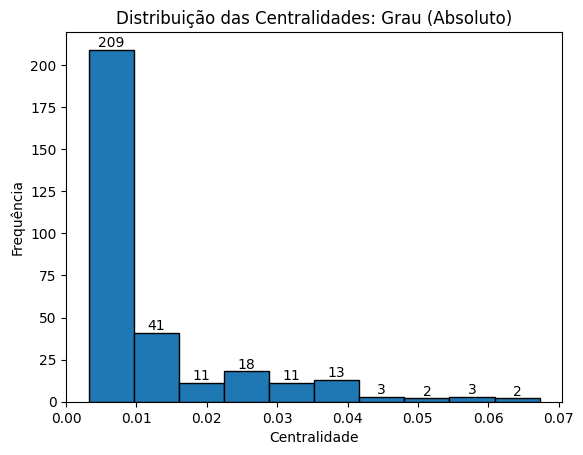

In [67]:
# Geração do histograma para a centralidades: Grau (Absoluto) 
dict_to_histogram(
    pyplot,
    absolute_degree_centralities,
    10,
    "Distribuição das Centralidades: Grau (Absoluto)",
    "Centralidade",
    "Frequência"
)

#### __Entrada__

A __centralidade de grau de entrada__ nos ajuda a entender o volume total de contratações realizadas por cada clube.

In [68]:
from networkx import in_degree_centrality

in_degree_centralities = get_sorted_centralities(graph, in_degree_centrality)

In [69]:
# Geração da tabela para centralidades: Grau (Entrada)
draw_styled_table(
    in_degree_centralities,
    "Grau (Entrada)",
    "Clubes"
)

,Clubes,Grau (Entrada)
0,San Diego FC,0.035256
1,LAFC,0.032051
2,Houston Dynamo FC,0.032051
3,CF Montréal,0.032051
4,Manchester City,0.028846
5,Nashville SC,0.028846
6,Inter Miami CF,0.025641
7,Chicago Fire FC,0.025641
8,Juventus,0.022436
9,Bayer Leverkusen,0.022436


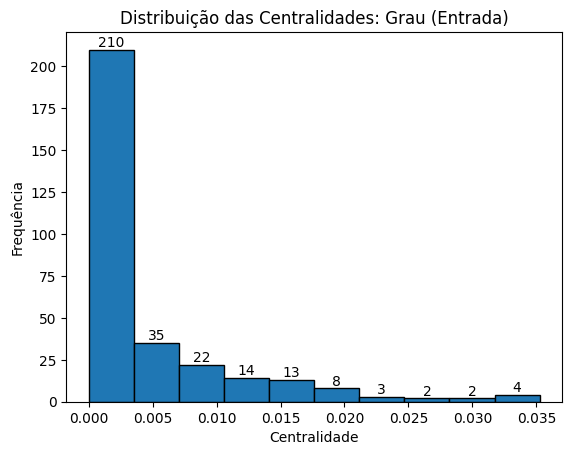

In [70]:
# Geração do histograma para a centralidades: Grau (Entrada)
dict_to_histogram(
    pyplot,
    in_degree_centralities,
    10,
    "Distribuição das Centralidades: Grau (Entrada)",
    "Centralidade",
    "Frequência"
)

#### __Saída__

A __centralidade de grau de saída__ nos ajuda a entender o volume total de transferências realizadas por cada clube.

In [71]:
from networkx import out_degree_centrality

out_degree_centralities = get_sorted_centralities(graph, out_degree_centrality)

In [72]:
# Geração da tabela para centralidades: Grau (Saída)
draw_styled_table(
    out_degree_centralities,
    "Grau (Saída)",
    "Clubes"
)

,Clubes,Grau (Saída)
0,Sem time,0.054487
1,Chelsea,0.048077
2,Aston Villa,0.044872
3,Brighton & Hove Albion,0.035256
4,Nottingham Forest,0.035256
5,AC Milan,0.032051
6,Liverpool,0.028846
7,Ajax,0.028846
8,Arsenal,0.025641
9,Manchester City,0.025641


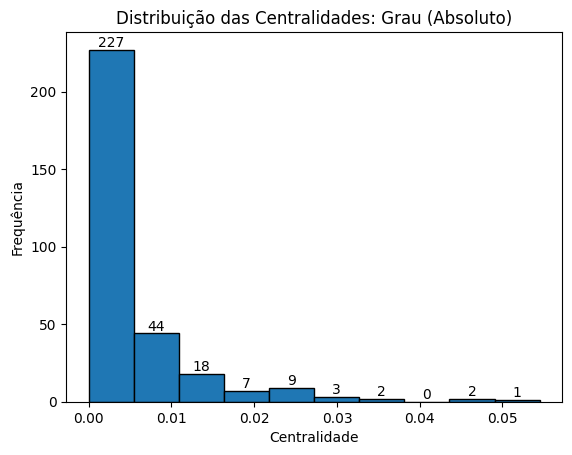

In [73]:
# Geração do histograma para a centralidades: Grau (Saída)
dict_to_histogram(
    pyplot,
    out_degree_centralities,
    10,
    "Distribuição das Centralidades: Grau (Absoluto)",
    "Centralidade",
    "Frequência"
)

### __Closeness (Proximidade)__

As __centralidade de proximidade__ são calculadas a partir do inverso da soma dos menores caminhos médios para os outros vértices do grafo. Esses dados nos ajudam a confirmar a tese levantada anteriormente - sobre a divissão em duas "macro comunidades" - porque aqui observamos dois perfis muito distintos entre os vértices, e uma distribuição que não se assemelha tanto a leis de potência.

In [74]:
from networkx import closeness_centrality

closeness_centralities = get_sorted_centralities(graph, closeness_centrality)

In [75]:
# Geração da tabela para centralidades: Closeness
draw_styled_table(
    closeness_centralities,
    "Closeness",
    "Clubes",
)

,Clubes,Closeness
0,Houston Dynamo FC,0.16076
1,Charlotte FC,0.15392
2,Cruz Azul,0.15385
3,San Diego FC,0.14824
4,LAFC,0.14764
5,CF Montréal,0.14546
6,Columbus Crew,0.14185
7,Real Betis,0.13956
8,Manchester City,0.13753
9,Bayern de Munique,0.13736


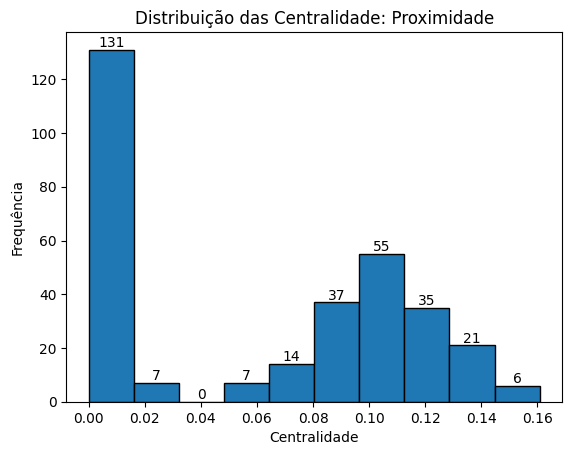

In [76]:
# Geração do histograma de centralidades: Closeness
dict_to_histogram(
    pyplot,
    closeness_centralities,
    10,
    "Distribuição das Centralidade: Proximidade",
    "Centralidade",
    "Frequência"
)

### __Betweenness (Intermediação)__

A __centralidade de intermediação__ é um dado vinculado a quantidade de caminhos que passam por um vértice. Esse dado nos ajuda a entender quais times operam como pontes entre diferentes comunidades, muitas vezes atuando como intermediadores de jogadores entre ligas internacionais.

In [77]:
from networkx import betweenness_centrality

betweenness_centralities = get_sorted_centralities(graph, betweenness_centrality)

In [78]:
# Geração da tabela para centralidades: Betweenness
draw_styled_table(
    betweenness_centralities,
    "Intermediação",
    "Clubes",
)

,Clubes,Intermediação
0,Chelsea,0.077133
1,Aston Villa,0.0767
2,Houston Dynamo FC,0.065557
3,LAFC,0.055175
4,D.C. United,0.049186
5,Palmeiras,0.049133
6,AFC Bournemouth,0.048008
7,CF Montréal,0.046163
8,Bayer Leverkusen,0.040742
9,Bayern de Munique,0.04049


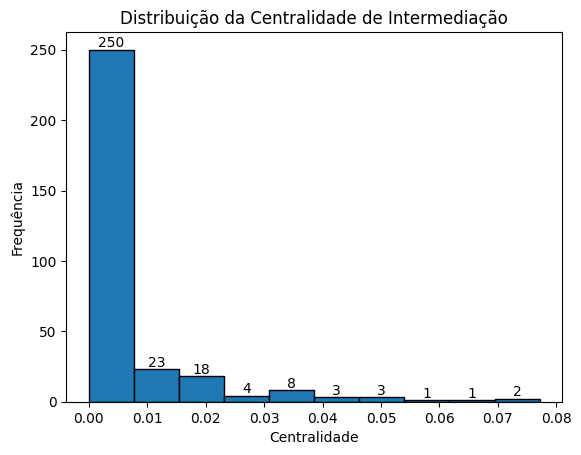

In [79]:
# Geração do histograma para centralidades: Betweenness
dict_to_histogram(
    pyplot,
    betweenness_centralities,
    10,
    "Distribuição da Centralidade de Intermediação",
    "Centralidade",
    "Frequência"
)

### __Eigenvector (Autovetor)__

A __centralidade de autovetor__ está associada ao quão influente um vértice é dentro do grafo.

In [80]:
from networkx import eigenvector_centrality

eigenvector_centralities = get_sorted_centralities(graph, eigenvector_centrality)

In [81]:
# Geração da tabela para centralidades: Eigenvector
draw_styled_table(
    eigenvector_centralities,
    "Autovetor",
    "Clubes"
)

,Clubes,Autovetor
0,Juventus,0.26324
1,AC Milan,0.21866
2,Cruz Azul,0.21233
3,Fiorentina,0.20782
4,Venezia,0.2022
5,Napoli,0.19696
6,LAFC,0.17351
7,Houston Dynamo FC,0.17327
8,San Diego FC,0.1723
9,Manchester City,0.16512


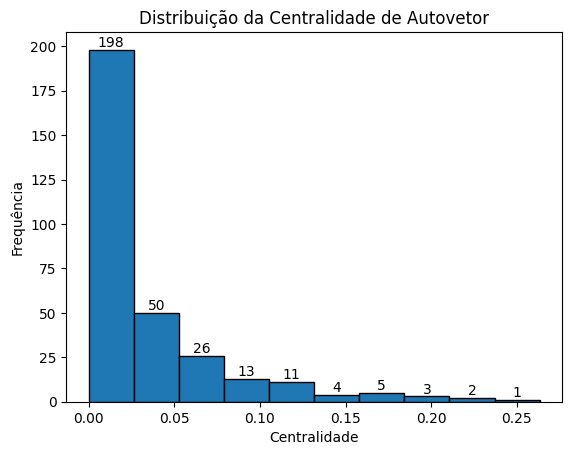

In [82]:
# Geração do histograma para centralidades: Eigenvector
dict_to_histogram(
    pyplot,
    eigenvector_centralities,
    10,
    "Distribuição da Centralidade de Autovetor",
    "Centralidade",
    "Frequência"
)

### __Pagerank__

O __pagerank__ é um algoritmo associado a não só ao quão influente um vértice é, mas também o quão influente os vértices com quem o primeiro está conectado. Essa é diretamente associada __centralidade de autovetor__, e serviu para indicar clubes fortemente atuantes no mercado de um modo geral, como também para apontar regiões de alta rotatividade de atletas.

In [83]:
from networkx import pagerank

pagerank_centralities = get_sorted_centralities(graph, pagerank)

In [84]:
# Geração da tabela para centralidades: Pagerank
draw_styled_table(
    pagerank_centralities,
    "Pagerank",
    "Clubes"
)

,Clubes,Pagerank
0,LAFC,0.029588
1,San Diego FC,0.019222
2,Sporting Kansas City,0.017134
3,FC Dallas,0.016765
4,CF Montréal,0.016518
5,Portland Timbers,0.016508
6,Houston Dynamo FC,0.016481
7,D.C. United,0.015412
8,Colorado Rapids,0.01418
9,Real Salt Lake,0.013021


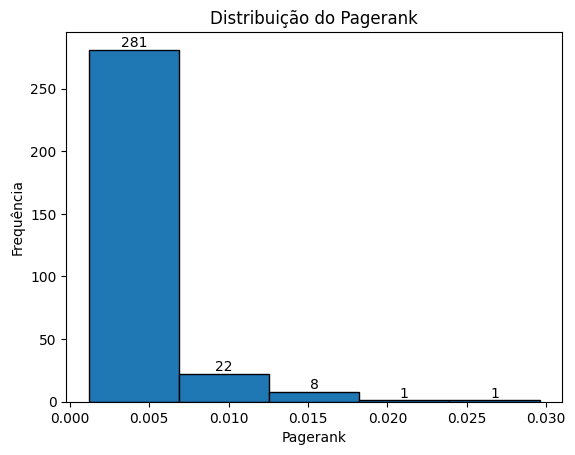

In [85]:
# Geração do histograma para centralidades: Pagerank
dict_to_histogram(
    pyplot,
    pagerank_centralities,
    5,
    "Distribuição do Pagerank",
    "Pagerank",
    "Frequência"
)

## __Comunidades da nossa modelagem__

Na nossa modelagem, utilizando do __método de Louvain__, encontramos algo em torno de 15 comunidades distintas, com uma modularidade de aproximadamente $ 0.597 $ em uma escala onde o máximo é 1, portanto considerada alta para um grafo, o que indica uma estrutura de comunidades forte, com conexões internas densas. Já a assortividade atingiu o valor de $ -0.277 $, pequena porém negativa o que indica que os clubes costumam se relacionar com outros de perfis diferentes.  



In [86]:
from networkx.algorithms.community import louvain_communities 
from src.communities import get_comunities

communities = get_comunities(graph, louvain_communities)

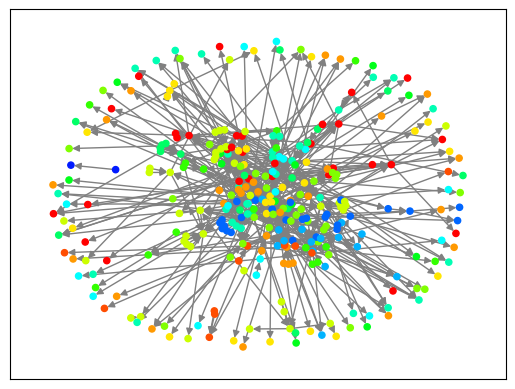

In [87]:
from src.visualization import draw_graph_communities

draw_graph_communities(pyplot, graph, layout, communities)